In [1]:
import sys

sys.path.append("../scripts")

import pandas as pd
import numpy as np
from tuner import ClassificationTuner, clean_training_data
from utils import (
    clean_training_data,
    split_dataset,
    get_x_and_y,
    validate_classification,
    make_submission,
)
from sklearn.model_selection import train_test_split

In [2]:
X,y = get_x_and_y("../data/training-with-satellite-features.csv")
X_train, X_test, y_train, y_test = split_dataset(X,y)
X_train, y_train = clean_training_data(X_train, y_train)

In [3]:
tuner = ClassificationTuner(study_name="dups-removed-xgb-added", n_trials=0, storage="sqlite:///../tuning/classification_tuning.db")
tuner.fit(X_train, y_train)


────────────────────────────────────────────────────────────
  OPTUNA CLASSIFICATION TUNING — RESULTS
────────────────────────────────────────────────────────────
  Trials completed : 300
  Scoring metric   : f1_macro  (maximize)
  Best CV score    : 0.759760

  Best parameters:
    model                          = xgboost
    scaler                         = maxabs
    use_pca                        = False
    xgb__colsample_bytree          = 0.9894051770359916
    xgb__learning_rate             = 0.014796300680186423
    xgb__max_depth                 = 6
    xgb__n_estimators              = 469
    xgb__subsample                 = 0.9192788431509102
────────────────────────────────────────────────────────────


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1635
           1       0.84      0.91      0.88      1897

    accuracy                           0.86      3532
   macro avg       0.86      0.86      0.86      3532
weighted avg       0.86      0.86      0.86      3532



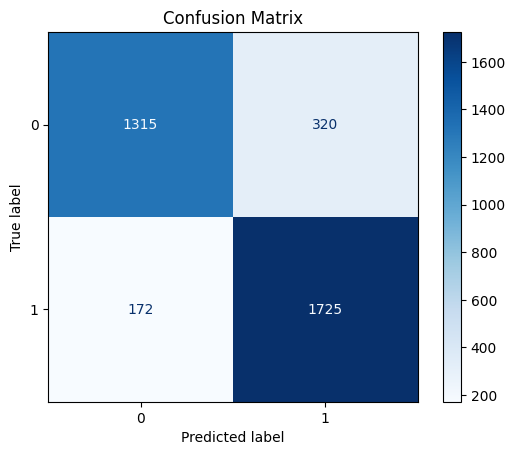

In [4]:
validate_classification(tuner.best_pipeline_, X_train, y_train)

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.69      0.72       771
           1       0.80      0.85      0.82      1123

    accuracy                           0.78      1894
   macro avg       0.78      0.77      0.77      1894
weighted avg       0.78      0.78      0.78      1894



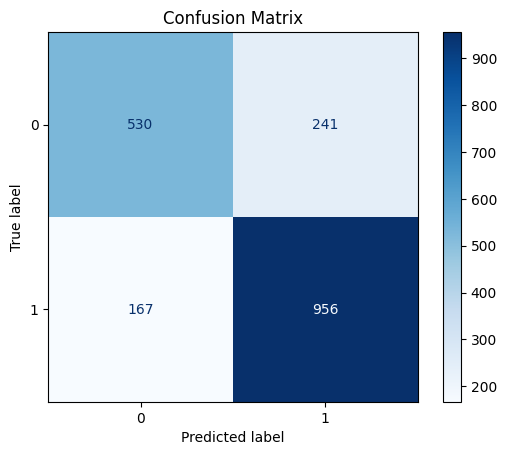

In [5]:
validate_classification(tuner.best_pipeline_, X_test, y_test)

In [7]:
## prediction
make_submission(
    "../data/test-with-satellite-features.csv",
    tuner.best_pipeline_,
    "../submissions/dups-removed-xgb.csv",
)